# Introduction to Data Analysis in R

First we need to load the essential packages in R that form the foundation of modern data analysis. The `tidyverse` is a collection of R packages designed for data science. It includes `dplyr` for data manipulation (like pandas in Python) and `ggplot2` for data visualization (like seaborn and matplotlib).

In [ ]:
# R packages are usually imported at the beginning of scripts/jupyter notebooks
# install.packages("tidyverse") # Run this once if you don't have it installed
library(tidyverse) # Equivalent of "import" in python

## Basic data structures in R
R provides two main types of structures for handling tabular data:

**Vector**: a one-dimensional array holding data of a single type (e.g., all numbers, or all text).

**Data Frame**: a two-dimensional data structure that holds data like a table with rows and columns. (The tidyverse uses an updated version of a data frame called a **tibble**).

## Object creation
### Vectors

In [2]:
# The c() function stands for 'combine' or 'concatenate'
s <- c(1, 3, 5, 7, 6, 8)
s

[1] 1 3 5 7 6 8

In [3]:
class(s)

[1] "numeric"

### Data Frames

In [4]:
df <- data.frame(
  one = c(1.0, 2.0, 3.0, 4.0), 
  two = c(4.0, 3.0, 2.0, 1.0)
)
df

one,two
<dbl>,<dbl>
1,4
2,3
3,2
4,1


In [5]:
# You can specify row names (though modern R workflows usually prefer keeping identifiers as a column)
rownames(df) <- c("a", "b", "c", "d")
df

,one,two
,<dbl>,<dbl>
a,1,4
b,2,3
c,3,2
d,4,1


In [6]:
rownames(df)

[1] "a" "b" "c" "d"

In [7]:
colnames(df)

[1] "one" "two"

## Column selection, addition, deletion

In [8]:
# Access a specific column using the $ operator
df$one

[1] 1 2 3 4

In [9]:
# Add columns based on other columns
df$three <- df$one * df$two
df$flag <- df$one > 2
df

,one,two,three,flag
,<dbl>,<dbl>,<dbl>,<lgl>
a,1,4,4,FALSE
b,2,3,6,FALSE
c,3,2,6,TRUE
d,4,1,4,TRUE


In [10]:
# Delete a column by assigning it NULL
df$two <- NULL
df

,one,three,flag
,<dbl>,<dbl>,<lgl>
a,1,4,FALSE
b,2,6,FALSE
c,3,6,TRUE
d,4,4,TRUE


In [11]:
# When inserting a single value, it will automatically be recycled to fill the column
df$foo <- "bar"
df

,one,three,flag,foo
,<dbl>,<dbl>,<lgl>,<chr>
a,1,4,FALSE,bar
b,2,6,FALSE,bar
c,3,6,TRUE,bar
d,4,4,TRUE,bar


## Indexing / selection
In Base R, you can subset using `[rows, columns]`. However, using `dplyr` functions like `filter()` is much more readable.

In [12]:
# Select specific rows by position (Base R)
df[1:3, ]

,one,three,flag,foo
,<dbl>,<dbl>,<lgl>,<chr>
a,1,4,FALSE,bar
b,2,6,FALSE,bar
c,3,6,TRUE,bar


In [13]:
# Select rows based on a condition (Base R)
df[df$flag == TRUE, ]

,one,three,flag,foo
,<dbl>,<dbl>,<lgl>,<chr>
c,3,6,TRUE,bar
d,4,4,TRUE,bar


In [14]:
# Select rows based on a condition (dplyr approach - cleaner!)
filter(df, flag == TRUE)

,one,three,flag,foo
,<dbl>,<dbl>,<lgl>,<chr>
c,3,6,TRUE,bar
d,4,4,TRUE,bar


## Console display
To view a small sample of a DataFrame, use `head()` and `tail()`. You can get a structural summary using `str()` or `glimpse()`.

In [15]:
# Create a large sample dataset
set.seed(42) # For reproducibility
df_large <- data.frame(
  patient_id = 1:100,
  age = sample(30:90, 100, replace = TRUE),
  score = rnorm(100, mean = 50, sd = 10)
)

In [16]:
head(df_large)

,patient_id,age,score
,<int>,<int>,<dbl>
1,1,78,42.18172
2,2,66,47.17930
3,3,30,67.81787
4,4,54,56.22660
5,5,39,21.62437
6,6,65,59.81397


In [17]:
tail(df_large, 4)

,patient_id,age,score
,<int>,<int>,<dbl>
97,97,57,47.11427
98,98,83,36.57876
99,99,31,52.61038
100,100,47,31.54982


In [18]:
# Glimpse shows you the structure, column types, and first few values
glimpse(df_large)

Rows: 100
Columns: 3
$ patient_id <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, …
$ age        <int> 78, 66, 30, 54, 39, 65, 47, 87, 78, 76, 53, 36, 65, 54, 66,…
$ score      <dbl> 42.18172, 47.17930, 67.81787, 56.22660, 21.62437, 59.81397,…


## Rename Columns

In [19]:
# Base R way to rename all columns (e.g., to uppercase)
colnames(df_large) <- toupper(colnames(df_large))
head(df_large)

,PATIENT_ID,AGE,SCORE
,<int>,<int>,<dbl>
1,1,78,42.18172
2,2,66,47.17930
3,3,30,67.81787
4,4,54,56.22660
5,5,39,21.62437
6,6,65,59.81397


In [20]:
# dplyr way to rename a specific column
df_large <- rename(df_large, Patient_ID = PATIENT_ID)
head(df_large, 2)

,Patient_ID,AGE,SCORE
,<int>,<int>,<dbl>
1,1,78,42.18172
2,2,66,47.17930


## Boolean reductions

In [21]:
df_bool <- data.frame(
  Age = c(45, 60, 37, 72),
  Score = c(88, 92, 79, 65)
)

# Are any patients older than 50?
any(df_bool$Age > 50)

# Are all patients older than 50?
all(df_bool$Age > 50)

[1] TRUE

[1] FALSE

## Descriptive statistics

In [22]:
df_stats <- data.frame(
  one = c(1, 2, 3, 4),
  two = c(5, 6, 7, 8)
)

# Column-wise mean
colMeans(df_stats)

one two 
2.5 6.5

In [23]:
# Summary statistics for the whole dataframe
summary(df_stats)

      one            two      
 Min.   :1.00   Min.   :5.00  
 1st Qu.:1.75   1st Qu.:5.75  
 Median :2.50   Median :6.50  
 Mean   :2.50   Mean   :6.50  
 3rd Qu.:3.25   3rd Qu.:7.25  
 Max.   :4.00   Max.   :8.00  

## Categorical Data Summaries
Clinical datasets are full of categorical variables (e.g., disease stage, readmission status). To quickly summarize these, we use `table()` or dplyr's `count()`.

In [24]:
df_cat <- data.frame(
  patient_id = 1:10,
  tumor_stage = c("Stage I", "Stage II", "Stage I", "Stage III", "Stage II", 
                  "Stage I", "Stage IV", "Stage II", "Stage I", "Stage II")
)

# Get raw counts for each category
table(df_cat$tumor_stage)


  Stage I  Stage II Stage III  Stage IV 
        4         4         1         1 

In [25]:
# Get relative frequencies (percentages)
prop.table(table(df_cat$tumor_stage)) * 100


  Stage I  Stage II Stage III  Stage IV 
       40        40        10        10 

## Finding Unique Values

In [26]:
df_visits <- data.frame(
  visit_id = c(101, 102, 103, 104, 105),
  patient_id = c("PT-001", "PT-001", "PT-002", "PT-003", "PT-002"),
  adverse_event = c("Nausea", "None", "Headache", "None", "nausea")
)

# How many unique patients are actually in this dataset?
length(unique(df_visits$patient_id))

# What are the unique adverse events logged?
unique(df_visits$adverse_event)

[1] 3

[1] "Nausea"   "None"     "Headache" "nausea"

## Working with Dates and Times
We use `as.Date()` (or functions from the `lubridate` package in tidyverse) to convert text into date objects.

In [27]:
df_dates <- data.frame(
  patient_id = c(1, 2, 3),
  admission_date = c("2023-01-10", "2023-02-15", "2023-03-01"),
  discharge_date = c("2023-01-14", "2023-02-28", "2023-03-02")
)

# Convert string columns to Date objects
df_dates$admission_date <- as.Date(df_dates$admission_date)
df_dates$discharge_date <- as.Date(df_dates$discharge_date)

# Calculate length of stay (LOS)
df_dates$length_of_stay_days <- as.numeric(difftime(df_dates$discharge_date, df_dates$admission_date, units="days"))
df_dates

patient_id,admission_date,discharge_date,length_of_stay_days
<dbl>,<date>,<date>,<dbl>
1,2023-01-10,2023-01-14,4
2,2023-02-15,2023-02-28,13
3,2023-03-01,2023-03-02,1


## Basic String Manipulation

In [28]:
df_strings <- data.frame(
  patient_id = 1:4,
  sex_entry = c("Male", "female ", " MALE", "Female")
)

# Clean the strings: make lowercase, then strip whitespace
df_strings$sex_clean <- trimws(tolower(df_strings$sex_entry))
table(df_strings$sex_clean)


female   male 
     2      2 

## Sorting
In the tidyverse, we use `arrange()` to sort data frames.

In [29]:
df_sort <- data.frame(
  Age = c(45, 60, 37, 52),
  Score = c(88, 92, 79, 85)
)

# Sort by Age ascending
arrange(df_sort, Age)

Age,Score
<dbl>,<dbl>
37,79
45,88
52,85
60,92


In [30]:
# Sort by Score descending
arrange(df_sort, desc(Score))

Age,Score
<dbl>,<dbl>
60,92
45,88
52,85
37,79


## Grouping and Aggregation (group_by and summarize)
The combination of the pipe operator `%>%`, `group_by()`, and `summarize()` is the bread and butter of EDA in R. It allows you to quickly generate "Table 1" style summary statistics across patient cohorts.

In [31]:
df_group <- data.frame(
  patient_id = 1:6,
  treatment = c("Drug A", "Placebo", "Drug A", "Placebo", "Drug A", "Placebo"),
  sex = c("M", "F", "F", "M", "M", "F"),
  baseline_score = c(55, 60, 52, 65, 58, 62),
  followup_score = c(85, 65, 88, 62, 90, 68)
)

# Calculate mean follow-up score by treatment group using the pipe (%>%) 
df_group %>%
  group_by(treatment) %>%
  summarize(mean_followup = mean(followup_score))

treatment,mean_followup
<chr>,<dbl>
Drug A,87.66667
Placebo,65.00000


In [32]:
# Group by multiple columns and apply multiple aggregate functions
df_group %>%
  group_by(treatment, sex) %>%
  summarize(
    count = n(),
    mean_baseline = mean(baseline_score),
    mean_followup = mean(followup_score),
    .groups = "drop"
  )

treatment,sex,count,mean_baseline,mean_followup
<chr>,<chr>,<int>,<dbl>,<dbl>
Drug A,F,1,52.0,88.0
Drug A,M,2,56.5,87.5
Placebo,F,2,61.0,66.5
Placebo,M,1,65.0,62.0


## Merging (Joins)
To combine datasets based on a common key (like `patient_id`), we use `inner_join`, `left_join`, etc.

In [33]:
patients <- data.frame(
  patient_id = c(1, 2, 3, 4),
  age = c(45, 60, 37, 52),
  sex = c("M", "F", "M", "F")
)
labs <- data.frame(
  patient_id = c(1, 2, 3, 5),
  creatinine = c(0.9, 1.2, 0.7, 1.0)
)

# Inner join: only patients in BOTH datasets remain
inner_join(patients, labs, by="patient_id")

patient_id,age,sex,creatinine
<dbl>,<dbl>,<chr>,<dbl>
1,45,M,0.9
2,60,F,1.2
3,37,M,0.7


In [34]:
# Left join: keeps all patients in the left (first) dataset, adds NAs where missing
left_join(patients, labs, by="patient_id")

patient_id,age,sex,creatinine
<dbl>,<dbl>,<chr>,<dbl>
1,45,M,0.9
2,60,F,1.2
3,37,M,0.7
4,52,F,NA


## Working with Missing Values (NA)

In [35]:
df_na <- data.frame(
  patient_id = 1:5,
  age = c(45, 60, NA, 52, 37),
  outcome_score = c(88, 75, 90, NA, 85)
)

# Check for NAs
is.na(df_na)

patient_id,age,outcome_score
FALSE,FALSE,FALSE
FALSE,FALSE,FALSE
FALSE,TRUE,FALSE
FALSE,FALSE,TRUE
FALSE,FALSE,FALSE


In [36]:
# Drop any row with at least one missing value
na.omit(df_na)

,patient_id,age,outcome_score
,<int>,<dbl>,<dbl>
1,1,45,88
2,2,60,75
5,5,37,85


In [37]:
# Replace NAs with a specific value (using tidyr::replace_na)
df_na %>% replace_na(list(age = 0, outcome_score = 0))

patient_id,age,outcome_score
<int>,<dbl>,<dbl>
1,45,88
2,60,75
3,0,90
4,52,0
5,37,85


## IO tools (text, CSV, MS Excel, …)

The `tidyverse` includes the `readr` package for reading and writing flat text files (like CSVs) and the `readxl` package for reading Excel files. These functions (like `read_csv()`) generally return a tibble (a modern R data frame). The corresponding writer functions are accessed like `write_csv()`.

| Format Type | Data Description | Reader       | Writer     |
|-------------|------------------|--------------|------------|
| text        | CSV              | `read_csv`   | `write_csv`|
| binary      | MS Excel         | `read_excel` | `write_xlsx` (via writexl package) |

In [38]:
# Reads in a csv file
# use read_tsv() for tab-separated files
df_csv <- read_csv("patients.csv")
df_csv

Rows: 10 Columns: 10
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): sex, treatment
dbl (8): patient_id, age, weight_kg, height_cm, blood_pressure_systolic, blo...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


patient_id,age,sex,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,treatment,outcome_score
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,45,Male,82,175,130,85,72,Yes,88
2,60,Female,70,162,145,90,78,No,75
3,37,Male,90,180,120,80,70,Yes,92
4,52,Female,65,158,135,88,76,No,80
5,29,Female,55,165,110,70,68,Yes,95
6,67,Male,88,172,150,92,82,No,70
7,41,Male,76,178,125,82,74,Yes,89
8,73,Female,68,160,155,95,85,No,65
9,50,Male,85,182,140,87,77,Yes,84


In [43]:
# If you don't want to assume the first row of the file is the header
read_csv("patients.csv", col_names = FALSE, show_col_types = FALSE)

X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
patient_id,age,sex,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,treatment,outcome_score
1,45,Male,82,175,130,85,72,Yes,88
2,60,Female,70,162,145,90,78,No,75
3,37,Male,90,180,120,80,70,Yes,92
4,52,Female,65,158,135,88,76,No,80
5,29,Female,55,165,110,70,68,Yes,95
6,67,Male,88,172,150,92,82,No,70
7,41,Male,76,178,125,82,74,Yes,89
8,73,Female,68,160,155,95,85,No,65


In [40]:
# Write a Data Frame to a csv file
df <- data.frame(
  patient_id = c(1, 2, 3),
  age = c(45, 60, 37),
  treatment = c("Yes", "No", "Yes")
)

# write_csv automatically excludes row names/indices, which is usually preferred
write_csv(df, "patients_output.csv")

In [41]:
# The readxl package is installed with tidyverse but needs to be loaded explicitly
library(readxl)

# Read excel file (Sheet1)
df_excel <- read_excel("patients.xlsx", sheet = "Sheet1")
df_excel

patient_id,age,sex,weight_kg,height_cm,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,treatment,outcome_score
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,45,Male,82,175,130,85,72,Yes,88
2,60,Female,70,162,145,90,78,No,75
3,37,Male,90,180,120,80,70,Yes,92
4,52,Female,65,158,135,88,76,No,80
5,29,Female,55,165,110,70,68,Yes,95
6,67,Male,88,172,150,92,82,No,70
7,41,Male,76,178,125,82,74,Yes,89
8,73,Female,68,160,155,95,85,No,65
9,50,Male,85,182,140,87,77,Yes,84


In [42]:
# Read all sheets from an Excel file into a list of data frames 
# (This is the R equivalent of pandas returning a dictionary of DataFrames)
sheet_names <- excel_sheets("patients.xlsx")
df_excel_all <- lapply(sheet_names, function(x) read_excel("patients.xlsx", sheet = x))

# Name the list elements after the sheet names for easy access
names(df_excel_all) <- sheet_names

# Access the data from 'Sheet2'
df_excel_all$Sheet2

patient_id,follow_up_months,baseline_score,followup_score,adverse_event,readmission
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,6,85,88,No,No
2,6,78,75,Yes,Yes
3,12,90,92,No,No
4,6,82,80,No,No
5,12,88,95,No,No
6,3,72,70,Yes,Yes
7,6,86,89,No,No
8,3,70,65,Yes,Yes
9,12,80,84,No,No


## Plotting with ggplot2
`ggplot2` uses a 'grammar of graphics' where you build a plot layer by layer using the `+` operator.

In [45]:
# Sample dataset for plotting
df_plot <- data.frame(
  age = c(45, 60, 37, 52, 29, 67, 41, 73, 50, 34),
  blood_pressure = c(120, 145, 110, 135, 115, 150, 125, 155, 140, 118),
  outcome_score = c(88, 75, 95, 80, 98, 70, 89, 65, 84, 93),
  treatment = c("Yes", "No", "Yes", "No", "Yes", "No", "Yes", "No", "Yes", "Yes")
)
df_plot

age,blood_pressure,outcome_score,treatment
<dbl>,<dbl>,<dbl>,<chr>
45,120,88,Yes
60,145,75,No
37,110,95,Yes
52,135,80,No
29,115,98,Yes
67,150,70,No
41,125,89,Yes
73,155,65,No
50,140,84,Yes


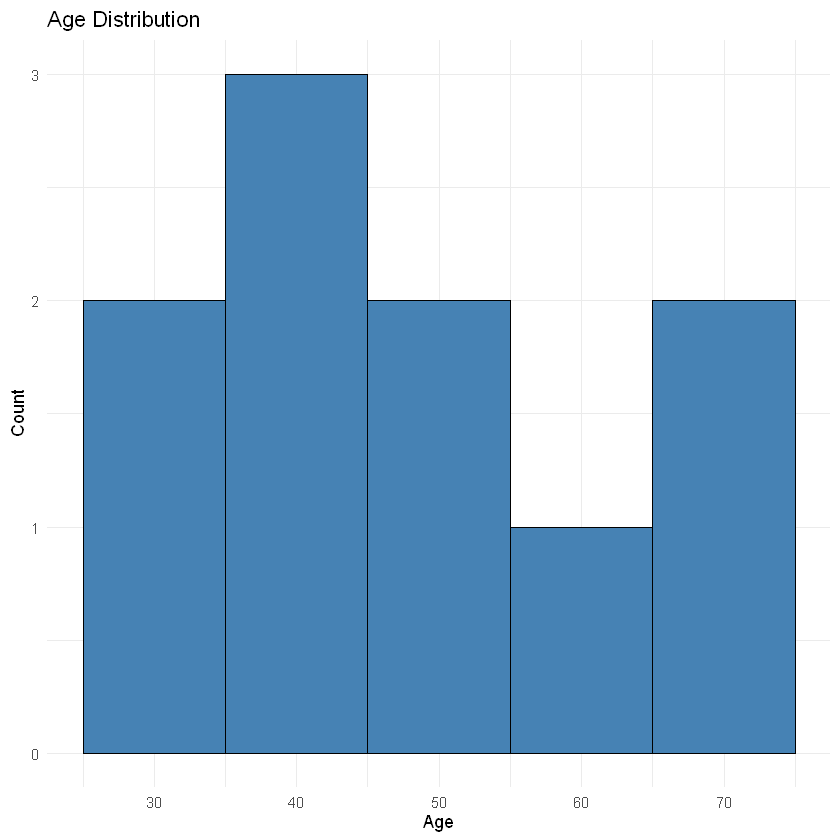

In [46]:
# Histogram: distribution of age
ggplot(df_plot, aes(x = age)) +
  geom_histogram(binwidth = 10, fill="steelblue", color="black") +
  theme_minimal() +
  labs(title = "Age Distribution", x = "Age", y = "Count")

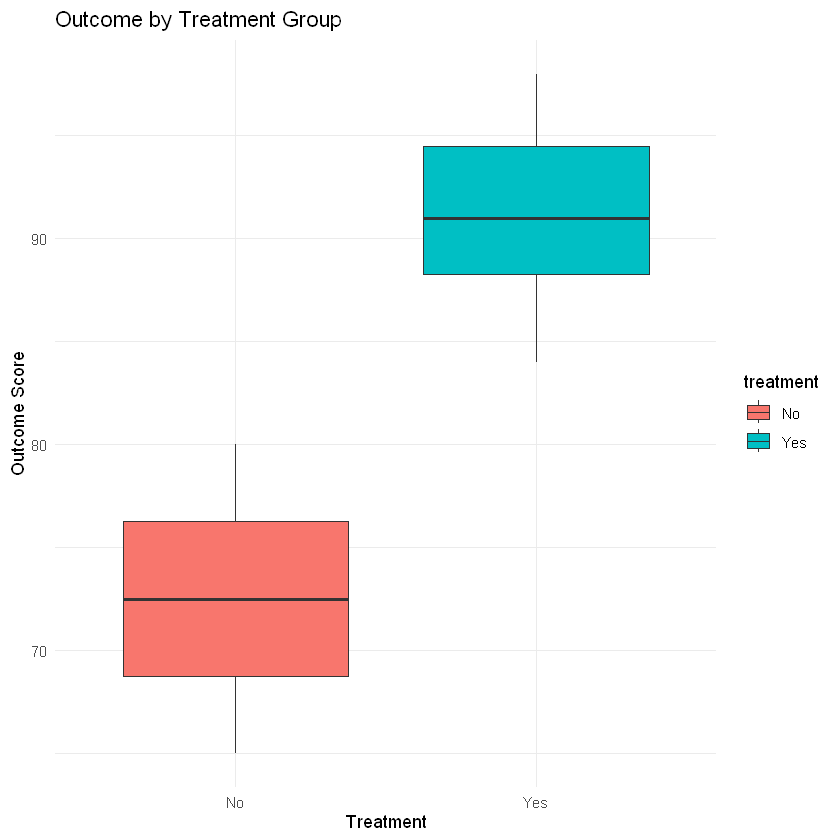

In [47]:
# Boxplot
ggplot(df_plot, aes(x = treatment, y = outcome_score, fill = treatment)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Outcome by Treatment Group", x = "Treatment", y = "Outcome Score")

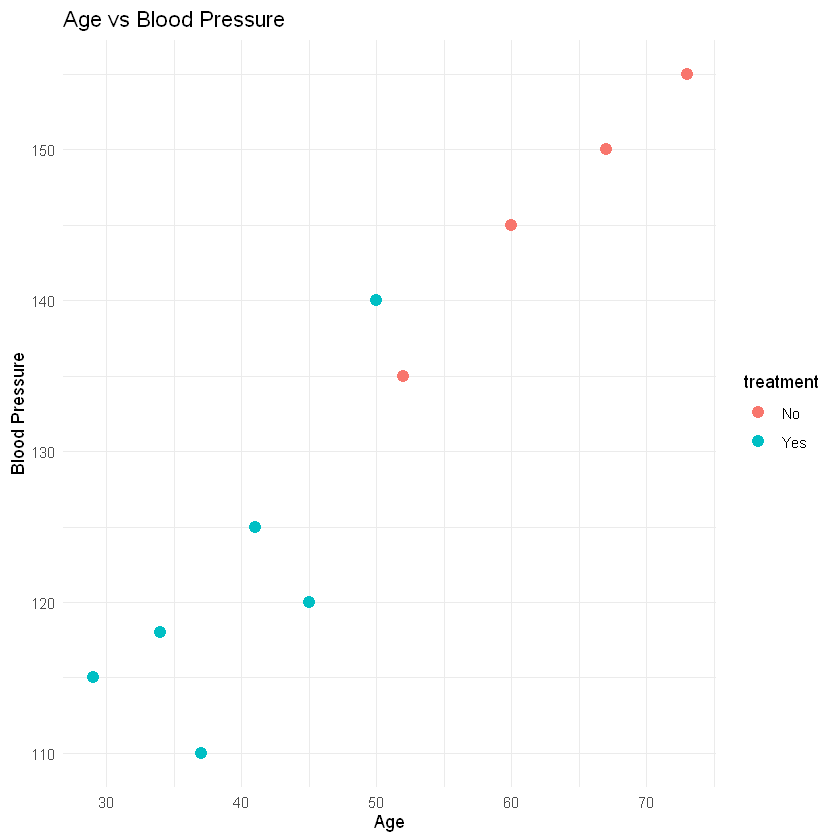

In [48]:
# Scatterplot
ggplot(df_plot, aes(x = age, y = blood_pressure, color = treatment)) +
  geom_point(size = 3) +
  theme_minimal() +
  labs(title = "Age vs Blood Pressure", x = "Age", y = "Blood Pressure")

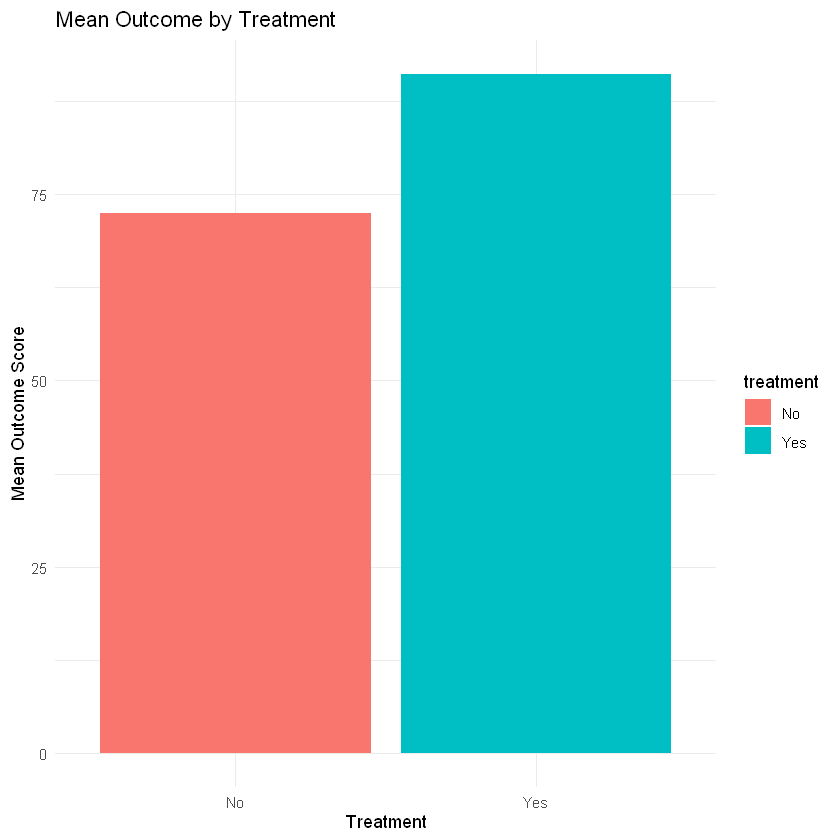

In [49]:
# Barplot of means
ggplot(df_plot, aes(x = treatment, y = outcome_score, fill = treatment)) +
  stat_summary(fun = mean, geom = "bar") +
  theme_minimal() +
  labs(title = "Mean Outcome by Treatment", x = "Treatment", y = "Mean Outcome Score")